/tmp/ipython-input-3543131979.py:19: RuntimeWarning: overflow encountered in exp
  return E0 * np.exp(-λ * t)


Initial Efficacy (E0): 20.37, Efficacy Degradation Constant(λ): 0.0044, Duration of Efficacy: 161.25 hours or 6.72 days
ANOVA (interval efficacy): F-statistic=1.15, p=3.35e-01


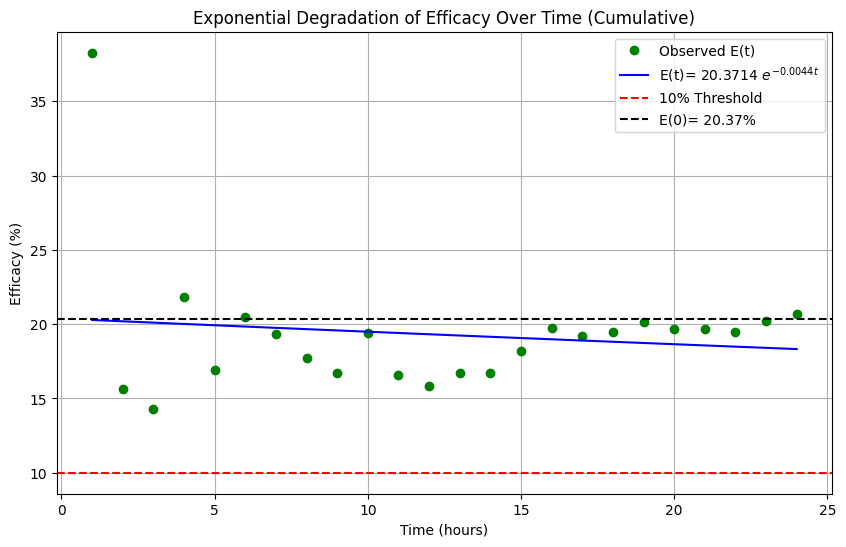

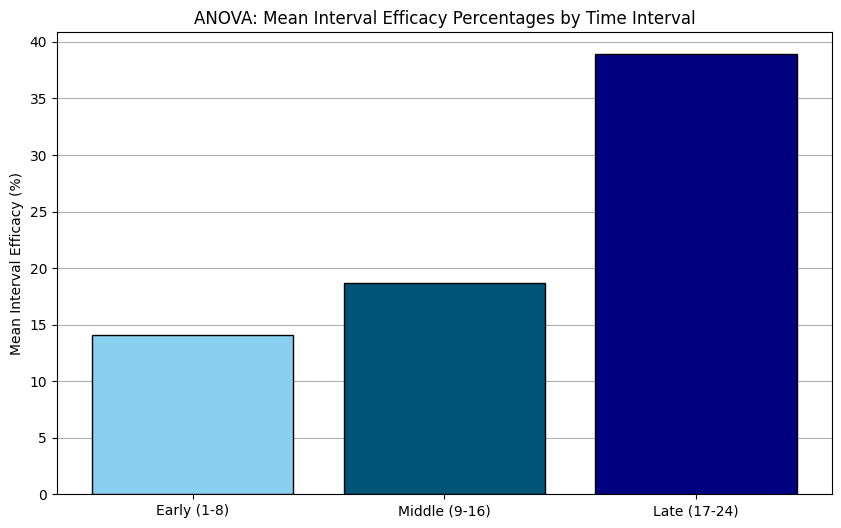

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from scipy.optimize import curve_fit
import math

# Data
time_hours = np.arange(1, 25)  # Time (1 to 24 hours)
control_visits = np.array([81, 128, 189, 275, 331, 405, 471, 536, 563, 614, 640, 668, 693, 712, 747, 785, 803, 826, 839, 869, 880, 887, 895, 900])
experiment_visits = np.array([50, 108, 162, 215, 275, 322, 380, 441, 469, 495, 534, 562, 577, 593, 611, 630, 649, 665, 670, 698, 707, 714, 714, 714])


# CUMULATIVE EFFICACY (for exponential degradation fit)
efficacy_percentages = 1 - (experiment_visits / control_visits)
efficacy_percentages *= 100  # Convert to percentage

# Exponential Degradation Model
def exponential_model(t, E0, λ):
    return E0 * np.exp(-λ * t)

# Fit the exponential model
params, _ = curve_fit(exponential_model, time_hours, efficacy_percentages)
E0, λ = params
t_duration = math.log(E0/10) / λ  # Time until efficacy drops below 10%
print(f"Initial Efficacy (E0): {E0:.2f}, Efficacy Degradation Constant(λ): {λ:.4f}, Duration of Efficacy: {t_duration:.2f} hours or {t_duration/24:.2f} days")


# INTERVAL EFFICACY (for ANOVA)

# Convert cumulative to interval
control_interval = np.diff(np.insert(control_visits, 0, 0))
experiment_interval = np.diff(np.insert(experiment_visits, 0, 0))

# Interval efficacy
efficacy_interval = 1 - (experiment_interval / control_interval)
efficacy_interval *= 100

# Split into groups
early = efficacy_interval[0:8]    # 1–8 hours
middle = efficacy_interval[8:16]  # 9–16 hours
late = efficacy_interval[16:24]   # 17–24 hours

# One-Way ANOVA
f_stat, p_anova = f_oneway(early, middle, late)
print(f"ANOVA (interval efficacy): F-statistic={f_stat:.2f}, p={p_anova:.2e}")

# 3) VISUALIZATIONS

# Exponential Degradation Graph (cumulative efficacy)
predicted_efficacy = exponential_model(time_hours, E0, λ)

plt.figure(figsize=(10, 6))
plt.plot(time_hours, efficacy_percentages, 'o', color='green', label="Observed E(t)")
plt.plot(time_hours, predicted_efficacy, '-', color='blue', label=f"E(t)= {E0:.4f} $e^{{{-λ:.4f}t}}$")
plt.title("Exponential Degradation of Efficacy Over Time (Cumulative)")
plt.xlabel("Time (hours)")
plt.ylabel("Efficacy (%)")
plt.axhline(10, color='red', linestyle='--', label='10% Threshold')
plt.axhline(E0, color='black', linestyle='--', label=f"E(0)= {E0:.2f}%")
plt.legend()
plt.grid()
plt.show()

# Bar plot for ANOVA (interval efficacy)
groups = ["Early (1-8)", "Middle (9-16)", "Late (17-24)"]
means = [np.mean(early), np.mean(middle), np.mean(late)]

plt.figure(figsize=(10, 6))
plt.bar(groups, means, color=['#89CFF0', '#005477', '#000080'], edgecolor='black', zorder=1000)
plt.title("ANOVA: Mean Interval Efficacy Percentages by Time Interval")
plt.ylabel("Mean Interval Efficacy (%)")
plt.grid(axis='y')
plt.show()